# 고상관계수 변수끼리의 


📂 [총 탐색량] 분석 시작...


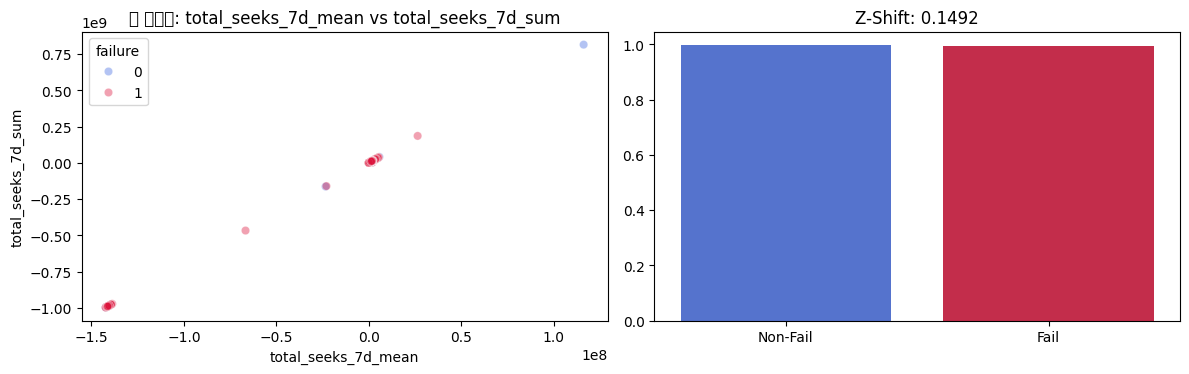

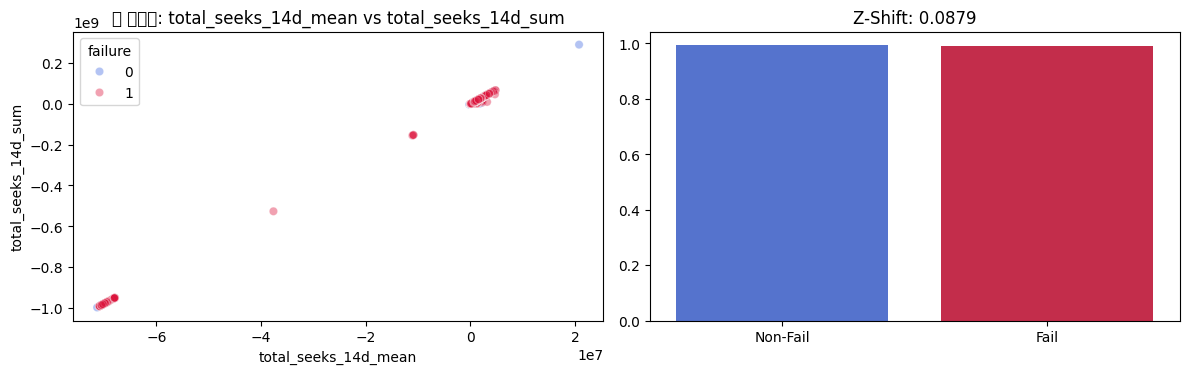

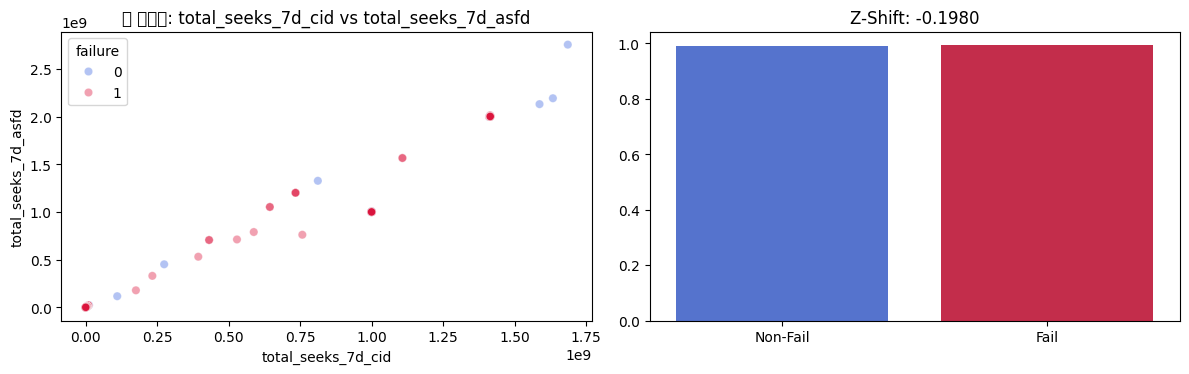

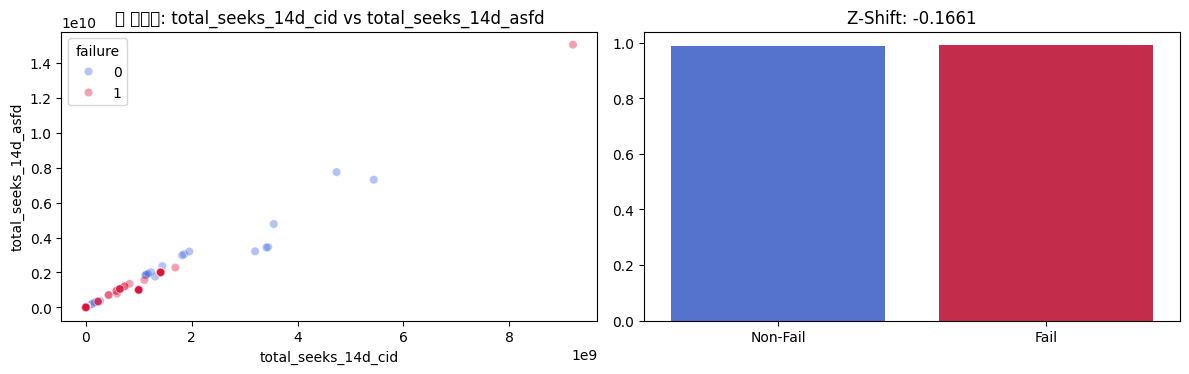

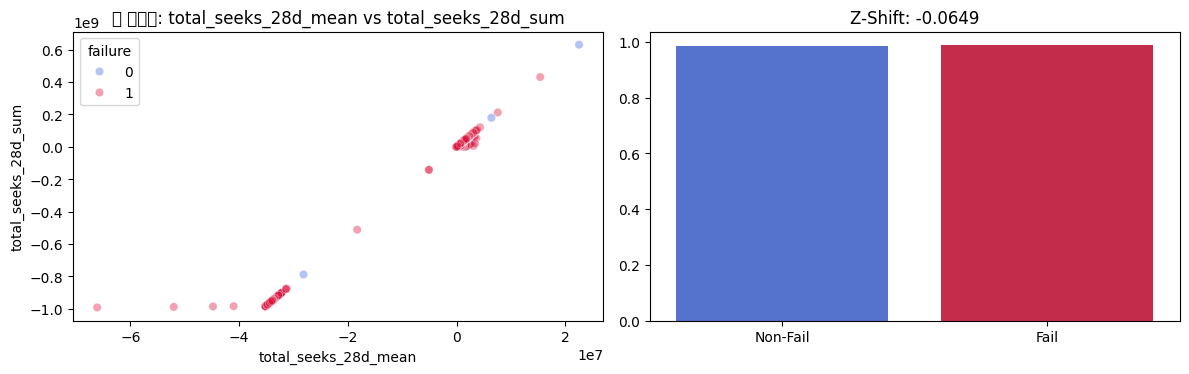

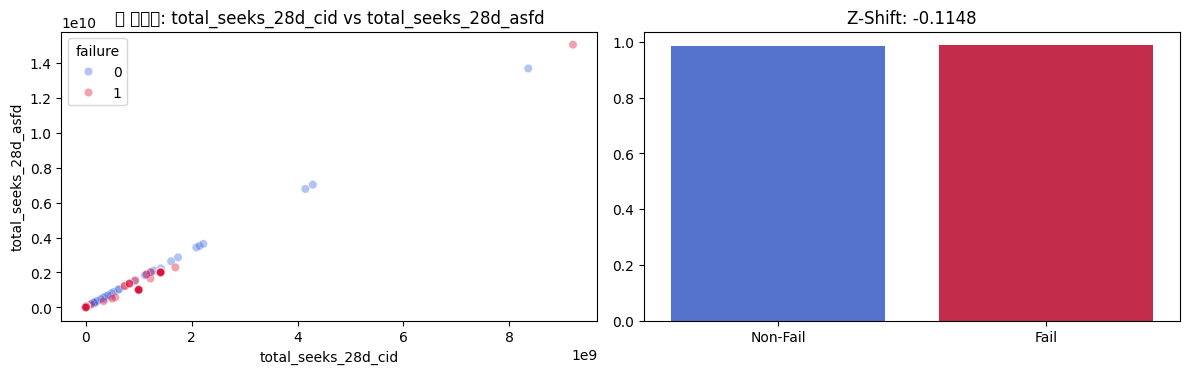

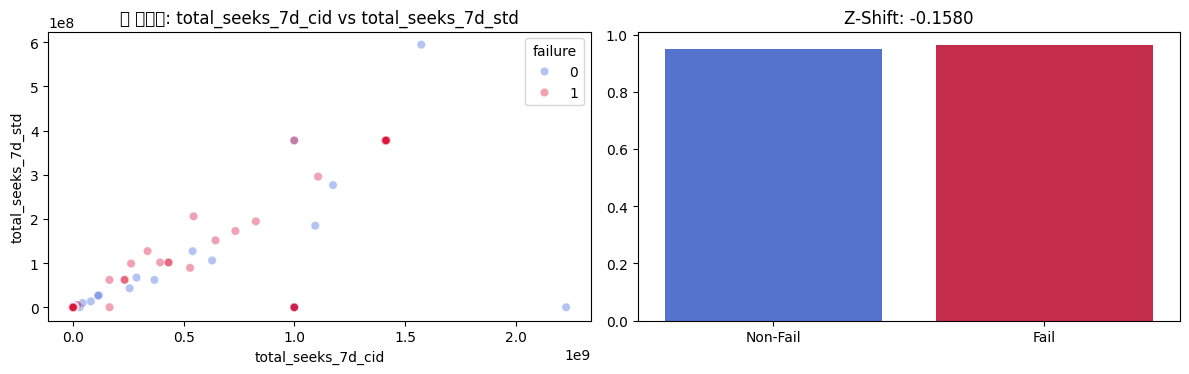

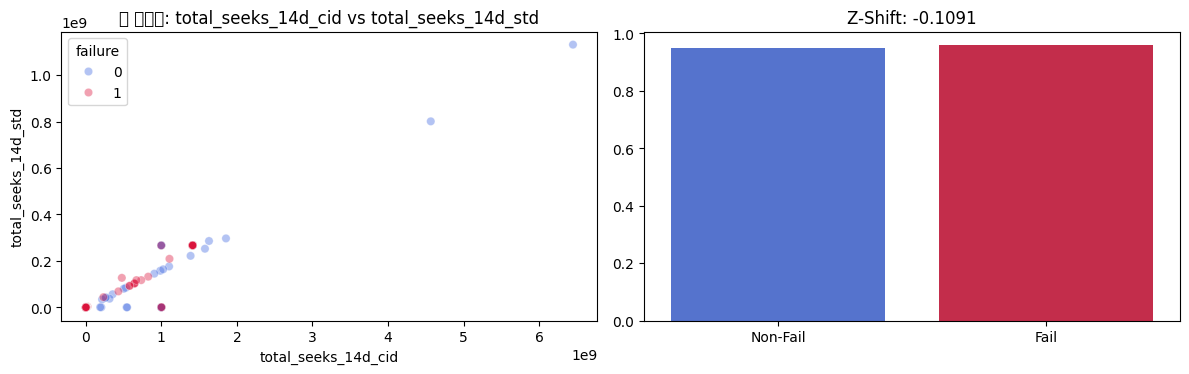

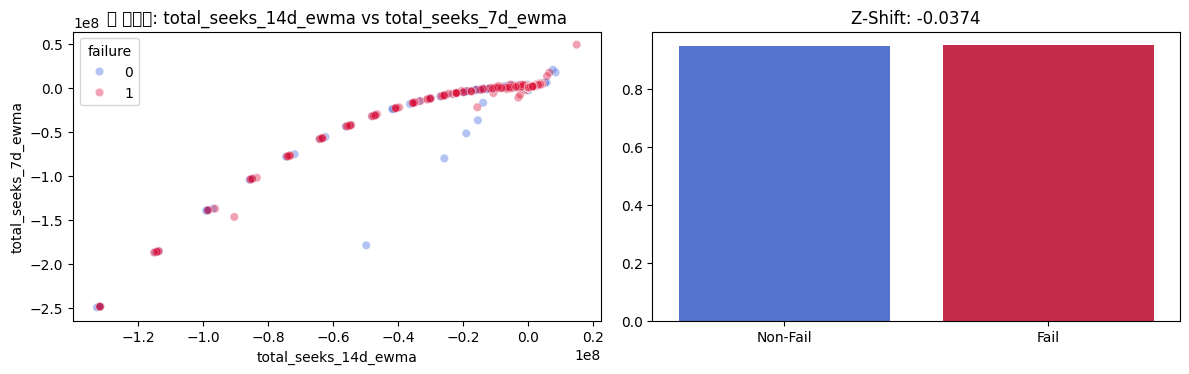

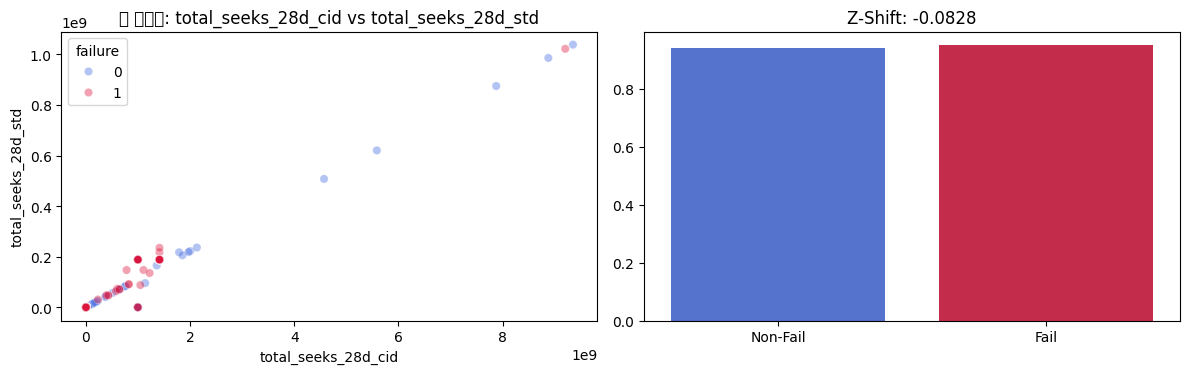

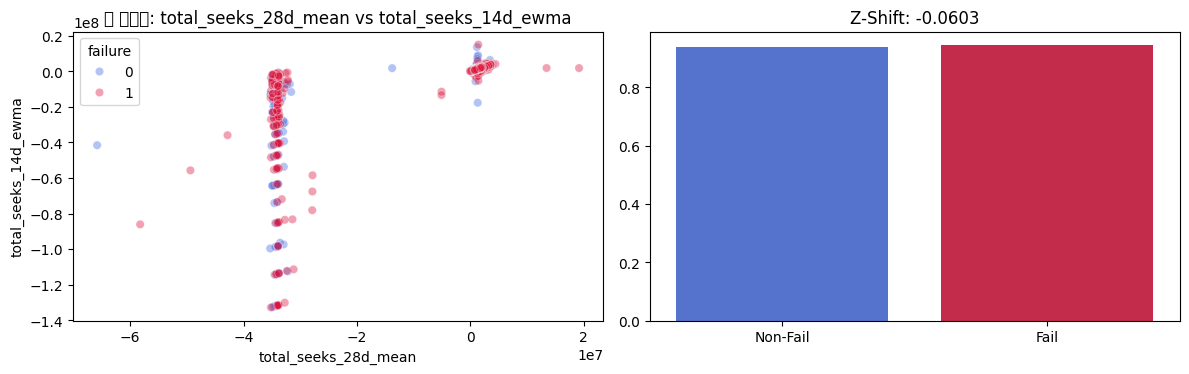

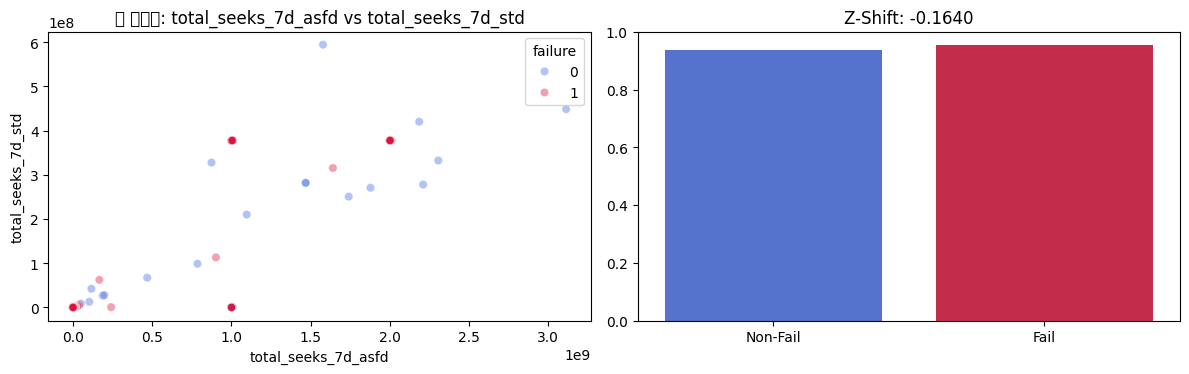

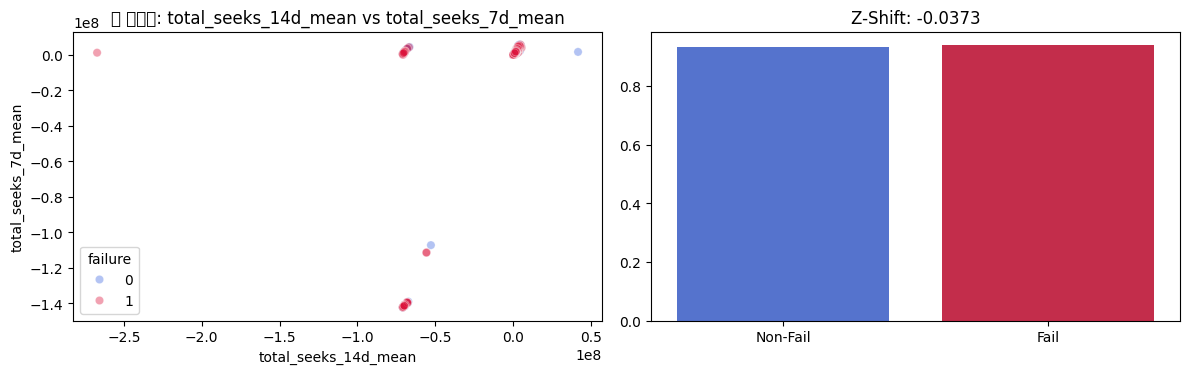

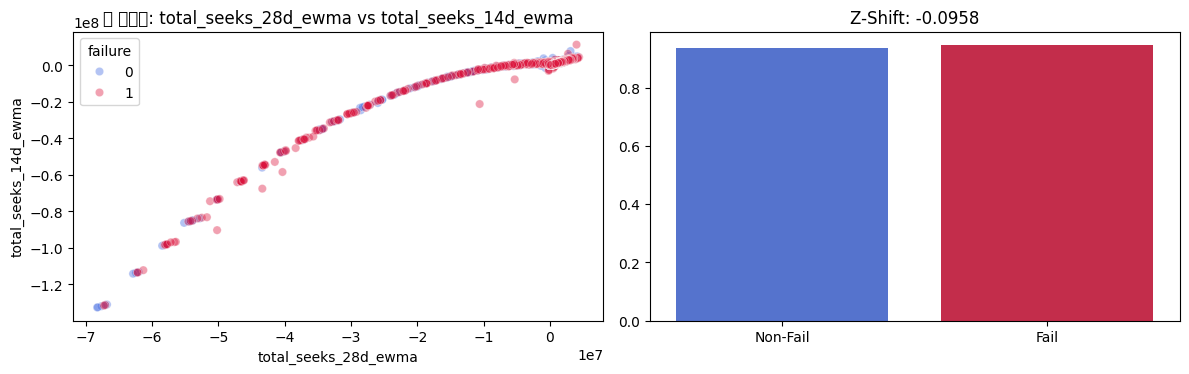

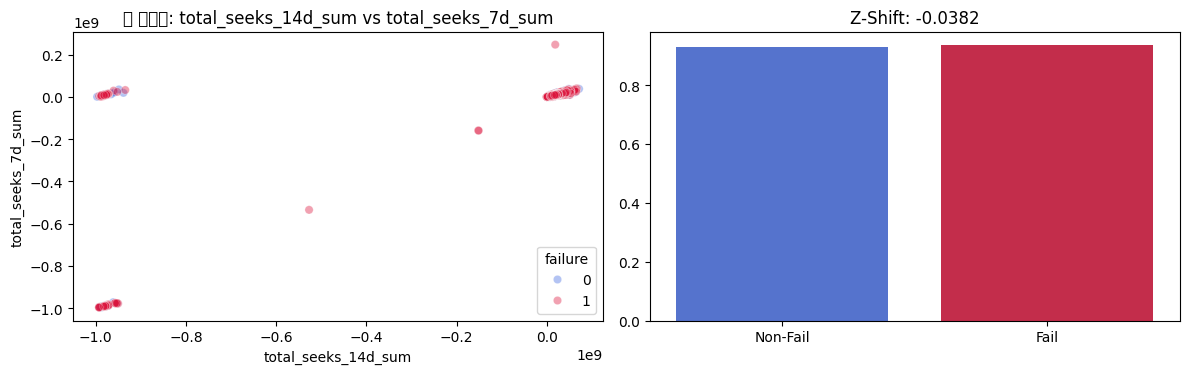

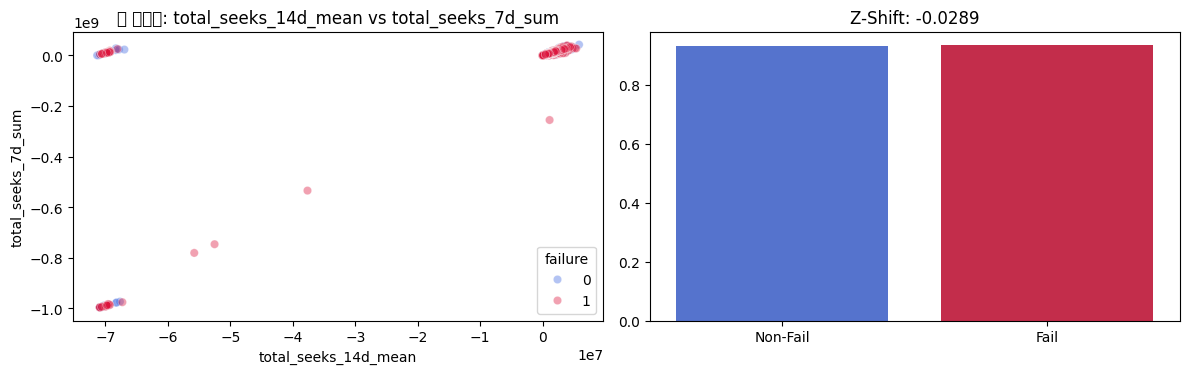

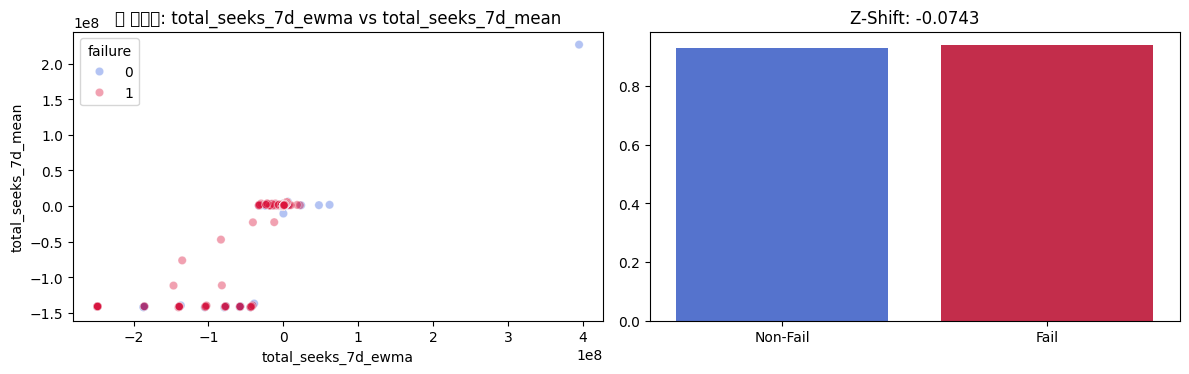

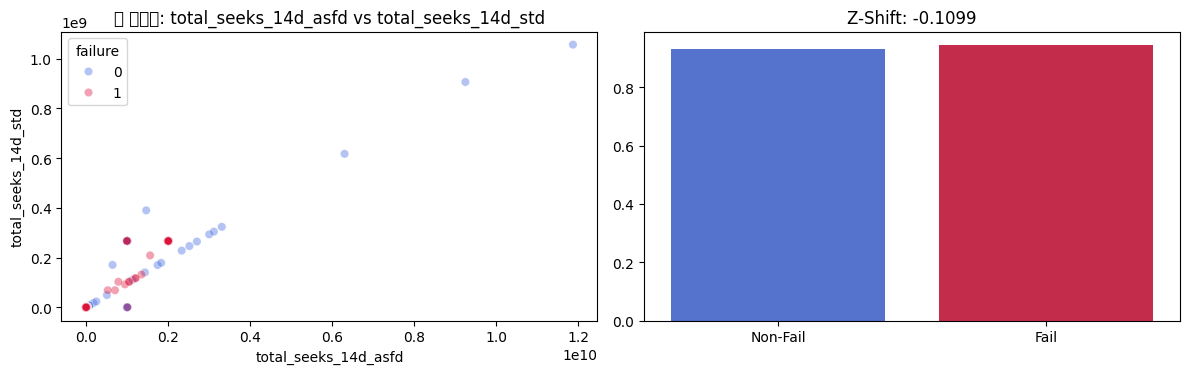

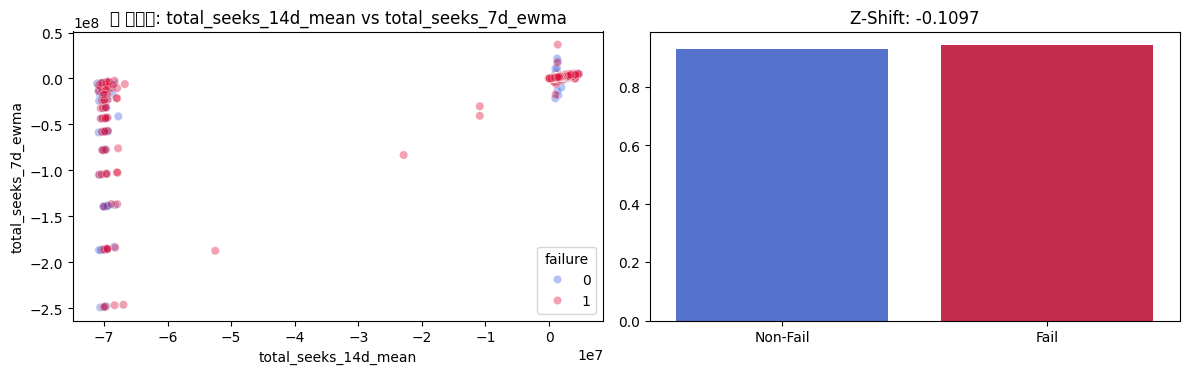

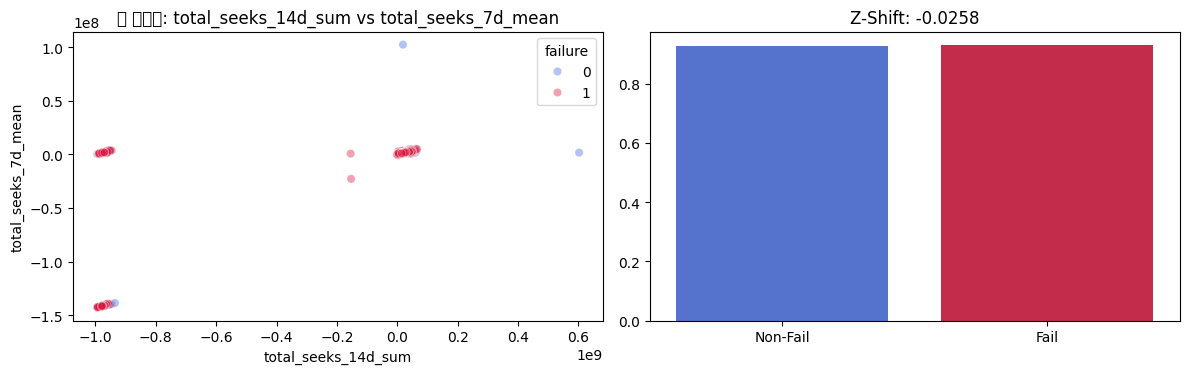

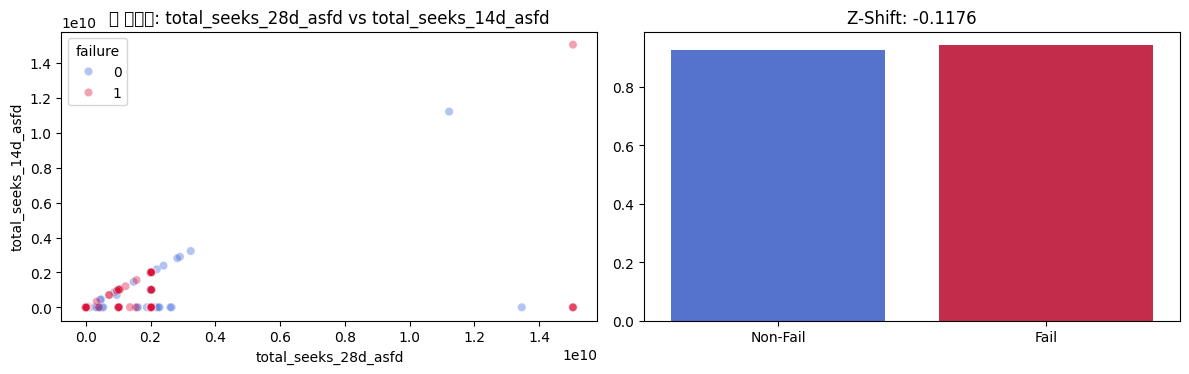

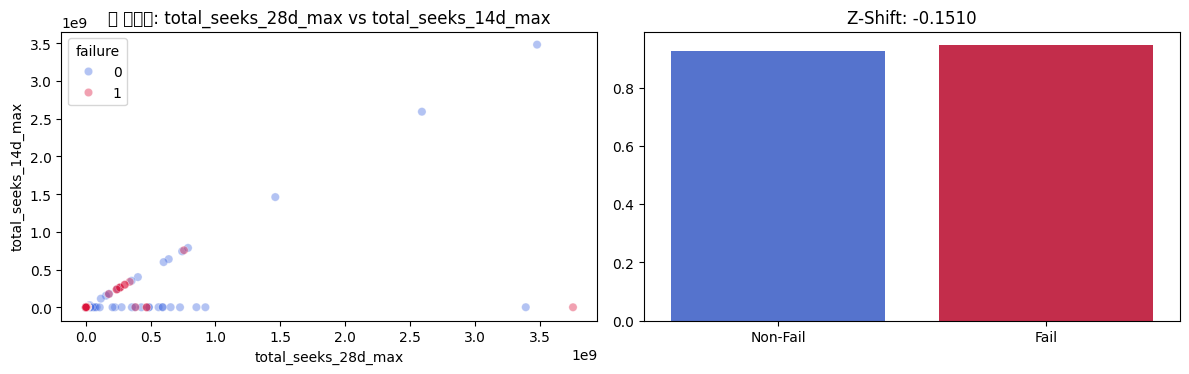

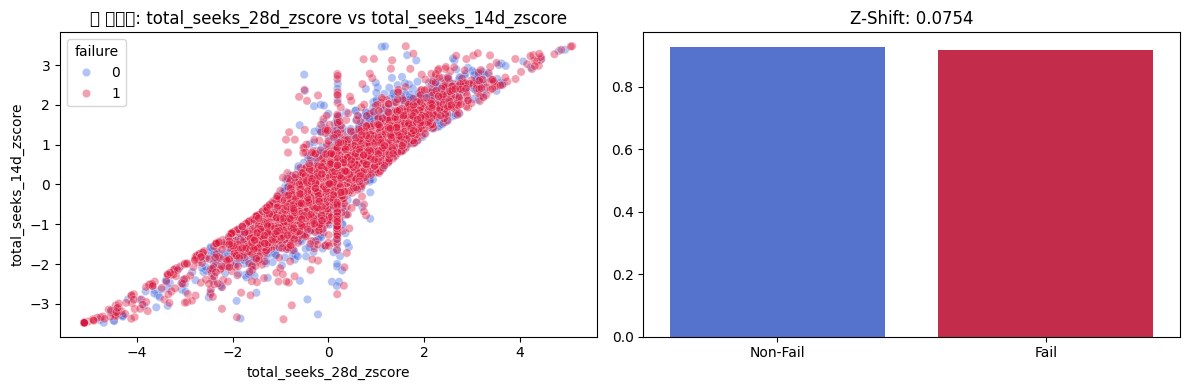

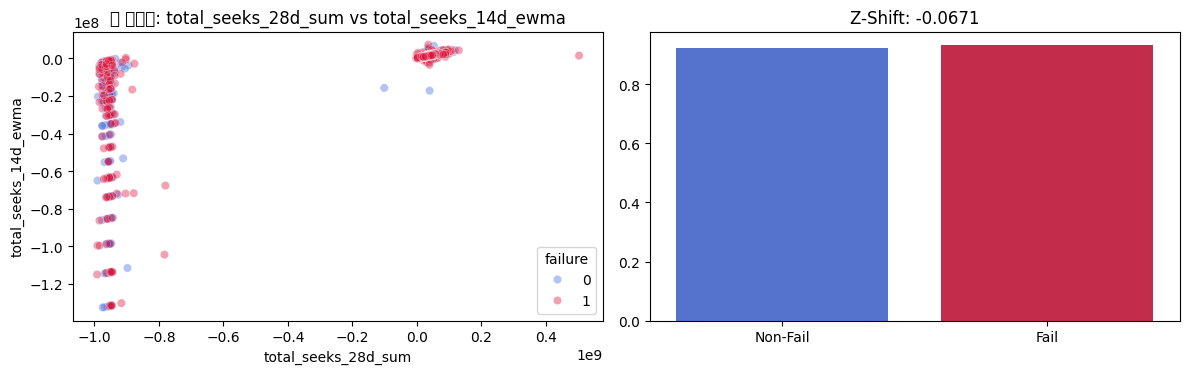

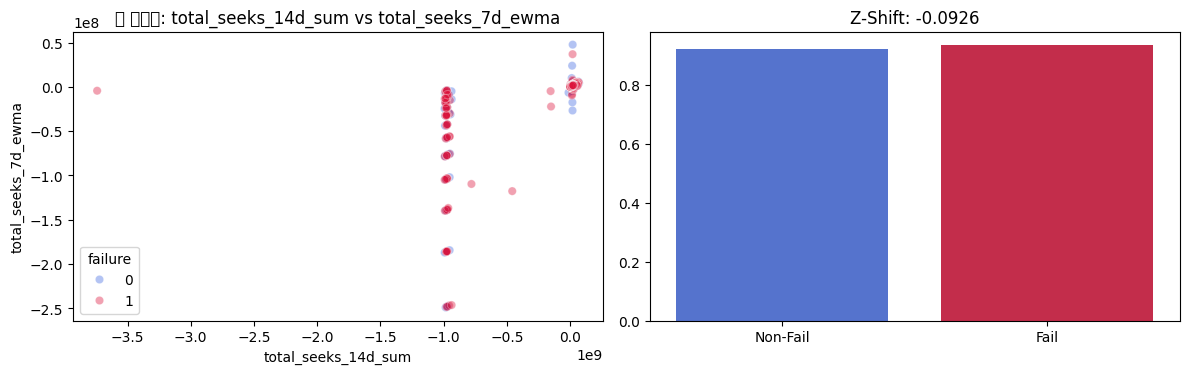

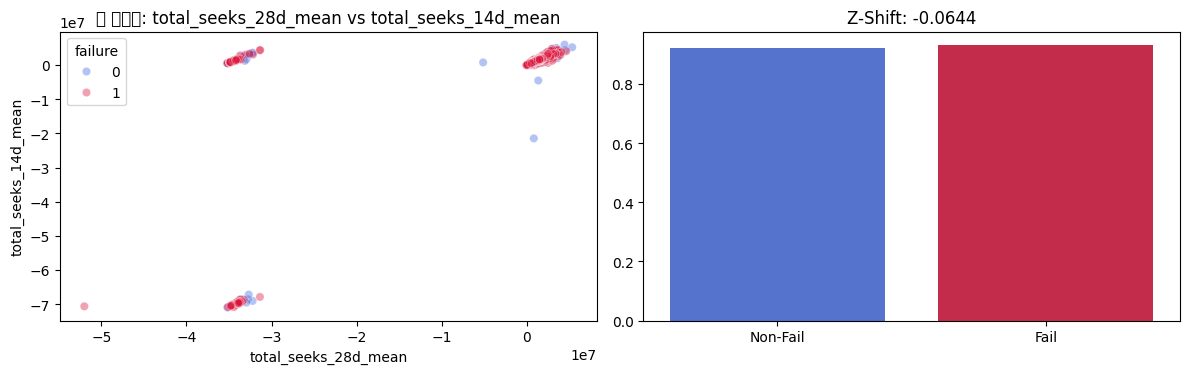

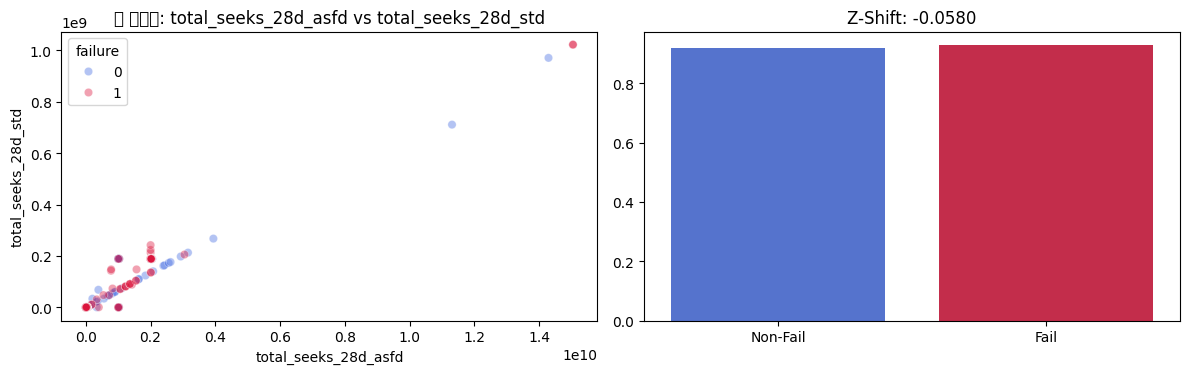

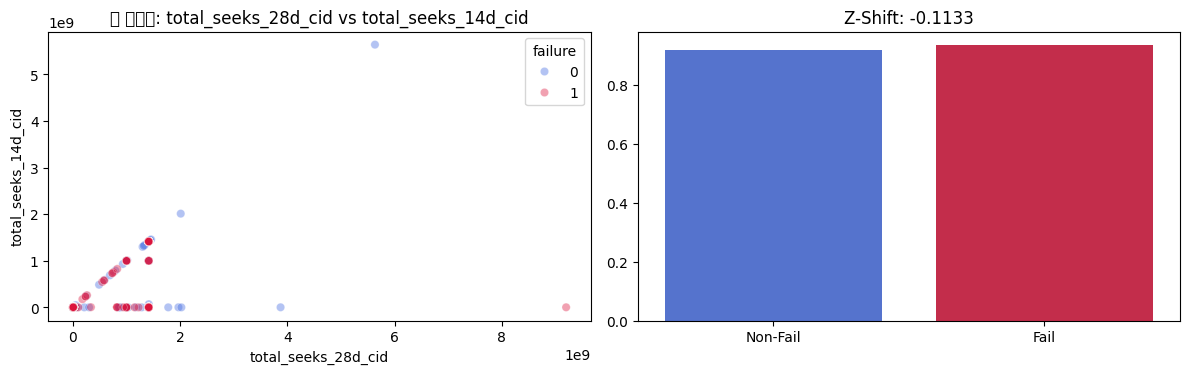

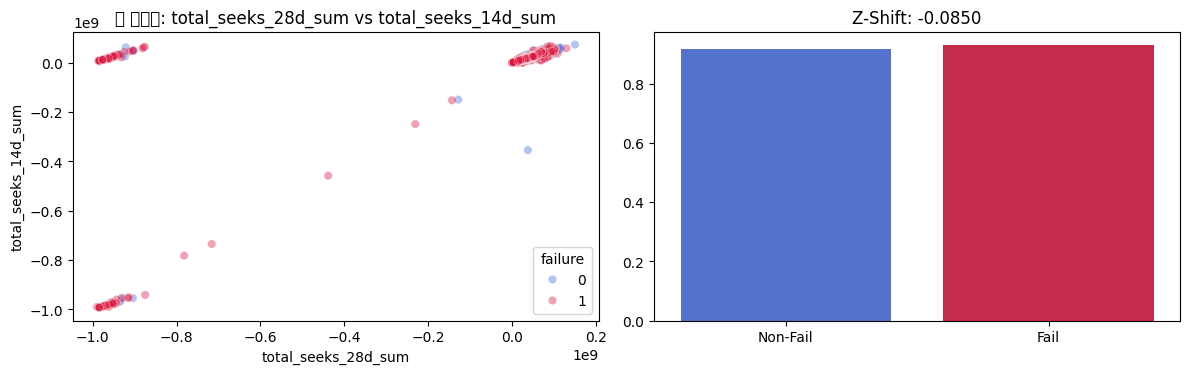

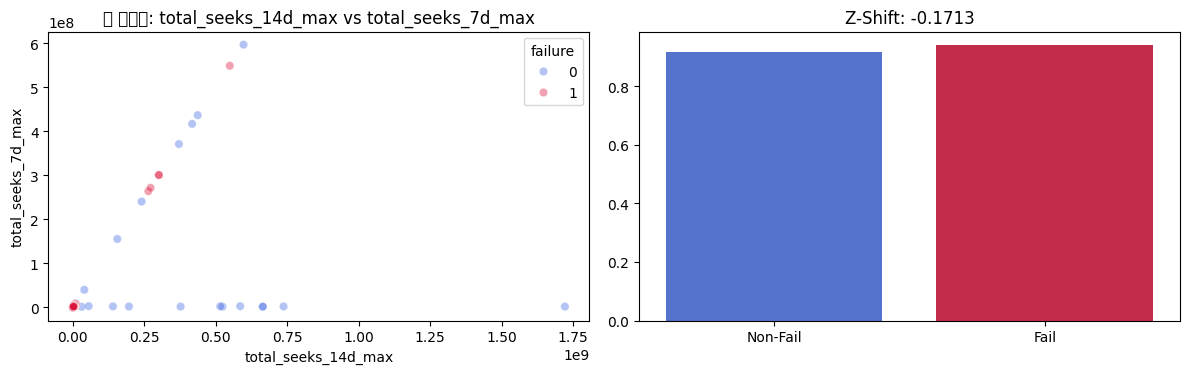

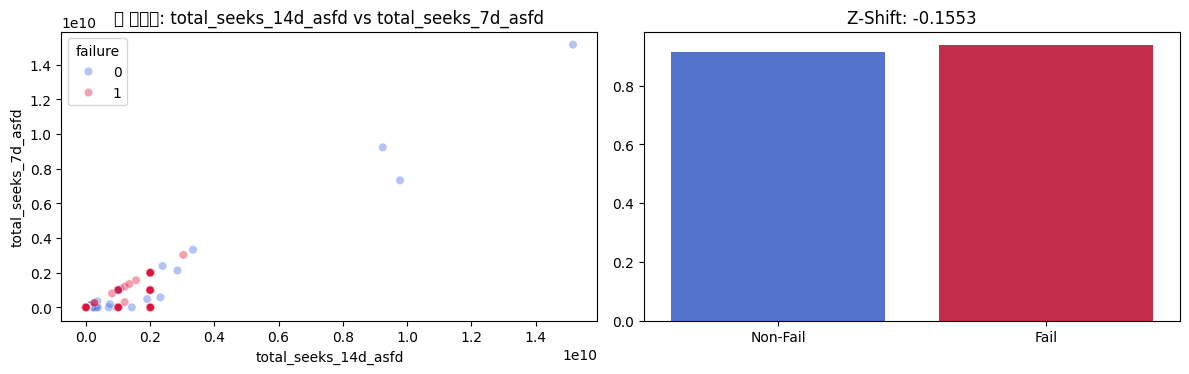

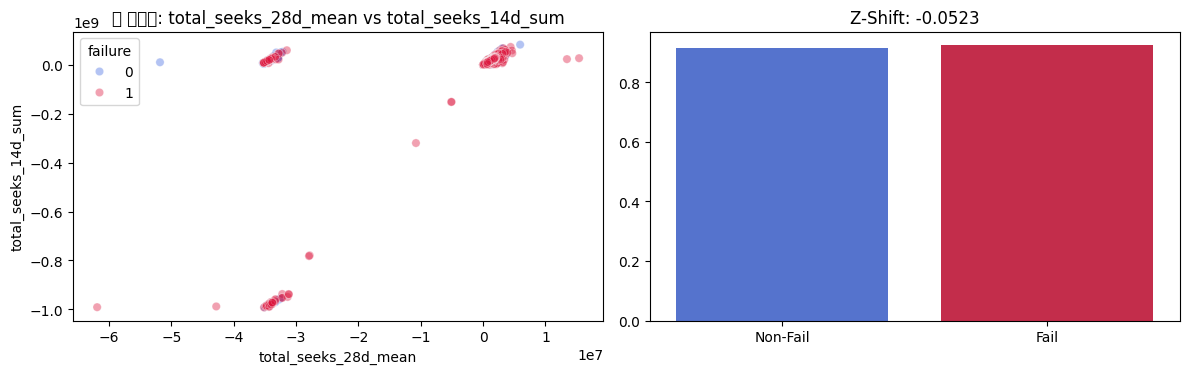

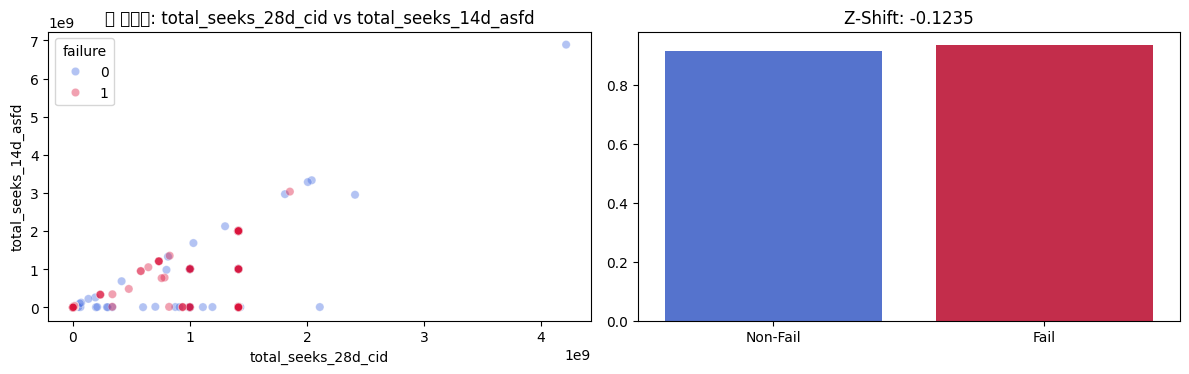

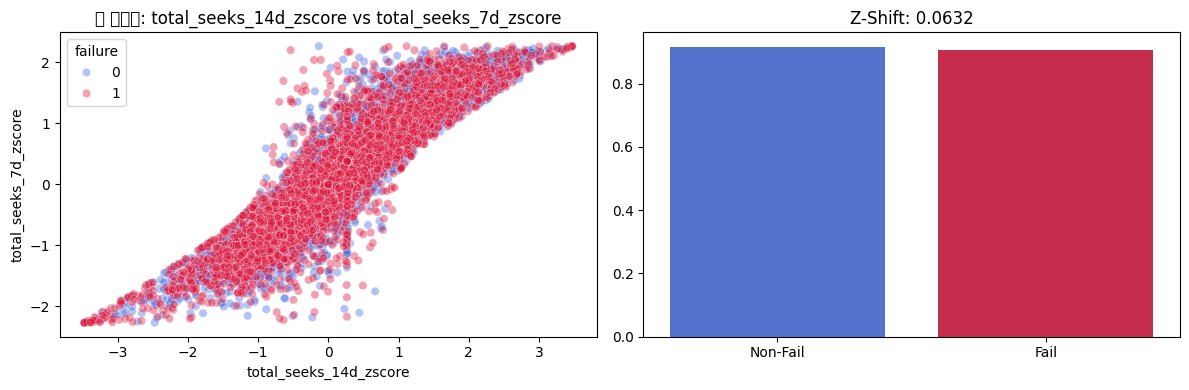

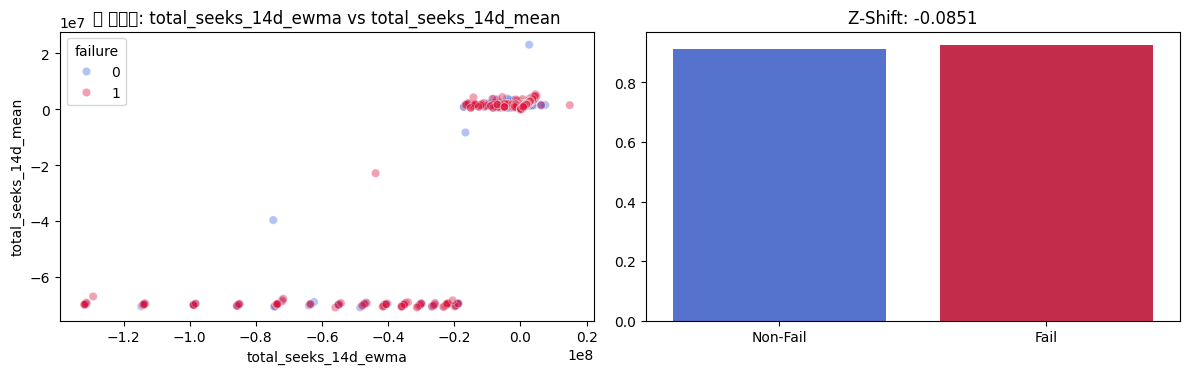

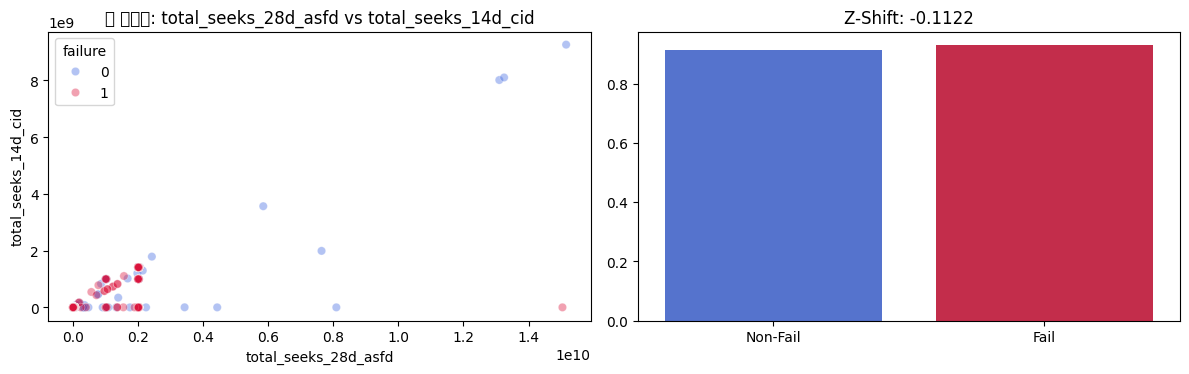

KeyboardInterrupt: 

In [ ]:
import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

# 1. 데이터 로드
path = r'..\data\rfe_sample_data\rfe_sample_train.parquet'
con = duckdb.connect()
df = con.execute(f"SELECT * FROM read_parquet('{path}')").df()
con.close()

# 2. 분석용 함수
def fisher_z_diff(r1, r2):
    r1 = np.clip(r1, -0.9999, 0.9999)
    r2 = np.clip(r2, -0.9999, 0.9999)
    z1 = 0.5 * np.log((1 + r1) / (1 - r1))
    z2 = 0.5 * np.log((1 + r2) / (1 - r2))
    return z1 - z2

# 3. 그룹별 데이터 정의
target_pairs_by_group = {
    "총 탐색량": [
        ("total_seeks_7d_mean", "total_seeks_7d_sum"), ("total_seeks_14d_mean", "total_seeks_14d_sum"),
        ("total_seeks_7d_cid", "total_seeks_7d_asfd"), ("total_seeks_14d_cid", "total_seeks_14d_asfd"),
        ("total_seeks_28d_mean", "total_seeks_28d_sum"), ("total_seeks_28d_cid", "total_seeks_28d_asfd"),
        ("total_seeks_7d_cid", "total_seeks_7d_std"), ("total_seeks_14d_cid", "total_seeks_14d_std"),
        ("total_seeks_14d_ewma", "total_seeks_7d_ewma"), ("total_seeks_28d_cid", "total_seeks_28d_std"),
        ("total_seeks_28d_mean", "total_seeks_14d_ewma"), ("total_seeks_7d_asfd", "total_seeks_7d_std"),
        ("total_seeks_14d_mean", "total_seeks_7d_mean"), ("total_seeks_28d_ewma", "total_seeks_14d_ewma"),
        ("total_seeks_14d_sum", "total_seeks_7d_sum"), ("total_seeks_14d_mean", "total_seeks_7d_sum"),
        ("total_seeks_7d_ewma", "total_seeks_7d_mean"), ("total_seeks_14d_asfd", "total_seeks_14d_std"),
        ("total_seeks_14d_mean", "total_seeks_7d_ewma"), ("total_seeks_14d_sum", "total_seeks_7d_mean"),
        ("total_seeks_28d_asfd", "total_seeks_14d_asfd"), ("total_seeks_28d_max", "total_seeks_14d_max"),
        ("total_seeks_28d_zscore", "total_seeks_14d_zscore"), ("total_seeks_28d_sum", "total_seeks_14d_ewma"),
        ("total_seeks_14d_sum", "total_seeks_7d_ewma"), ("total_seeks_28d_mean", "total_seeks_14d_mean"),
        ("total_seeks_28d_asfd", "total_seeks_28d_std"), ("total_seeks_28d_cid", "total_seeks_14d_cid"),
        ("total_seeks_28d_sum", "total_seeks_14d_sum"), ("total_seeks_14d_max", "total_seeks_7d_max"),
        ("total_seeks_14d_asfd", "total_seeks_7d_asfd"), ("total_seeks_28d_mean", "total_seeks_14d_sum"),
        ("total_seeks_28d_cid", "total_seeks_14d_asfd"), ("total_seeks_14d_zscore", "total_seeks_7d_zscore"),
        ("total_seeks_14d_ewma", "total_seeks_14d_mean"), ("total_seeks_28d_asfd", "total_seeks_14d_cid"),
        ("total_seeks_14d_cid", "total_seeks_7d_cid"), ("total_seeks_14d_asfd", "total_seeks_7d_cid"),
        ("total_seeks_28d_sum", "total_seeks_14d_mean"), ("total_seeks_14d_ewma", "total_seeks_14d_sum"),
        ("total_seeks_14d_cid", "total_seeks_7d_asfd"), ("total_seeks_28d_mean", "total_seeks_7d_ewma")
    ],
    "총 읽기량": [
        ("total_reads_28d_mean", "total_reads_28d_sum"), ("s242_28d_mean", "s242_28d_sum"),
        ("s242_28d_cid", "s242_28d_asfd"), ("s242_28d_ewma", "s242_28d_mean"),
        ("s242_28d_cid", "s242_28d_std"), ("s242_28d_ewma", "s242_28d_sum"),
        ("total_reads_28d_cid", "total_reads_28d_asfd"), ("s242_28d_asfd", "s242_28d_std"),
        ("s242_28d_std", "s242_28d_max"), ("s242_28d_cid", "s242_28d_max"),
        ("s242_28d_asfd", "s242_28d_max"), ("total_reads_28d_cid", "total_reads_28d_std"),
        ("s242_28d_mean", "s242_28d_max"), ("s242_28d_sum", "s242_28d_max"),
        ("s242_28d_ewma", "s242_28d_max")
    ],
    "총 기록량": [
        ("s241_28d_ewma", "s241_28d_mean"), ("s241_28d_mean", "s241_28d_sum"),
        ("s241_28d_cid", "s241_28d_asfd"), ("s241_28d_ewma", "s241_28d_sum"),
        ("s241_28d_std", "s241_28d_max"), ("s241_28d_cid", "s241_28d_std"),
        ("s241_28d_cid", "s241_28d_max"), ("s241_28d_asfd", "s241_28d_std"),
        ("s241_28d_mean", "s241_28d_max"), ("s241_28d_asfd", "s241_28d_max"),
        ("s241_28d_sum", "s241_28d_max"), ("s241_28d_ewma", "s241_28d_max")
    ],
    "기본 I/O 이상": [("timeout_severity_ratio", "timeout_read_density")],
    "열 스트레스": [
        ("s190_28d_ewma", "s190_28d_mean"), ("s190_28d_ewma", "s190_14d_mean"),
        ("s190_14d_mean", "s190_7d_mean"), ("s190_28d_mean", "s190_14d_mean"),
        ("s190_28d_ewma", "s190_7d_mean"), ("s190_28d_mean", "s190_7d_mean")
    ],
    "온도 수준": [
        ("s194_14d_mean", "s194_7d_mean"), ("s194_28d_mean", "s194_14d_mean"),
        ("s194_28d_mean", "s194_7d_mean"), ("thermal_stress_index", "s194_over40_7d_count")
    ],
    "직접 손상 발생": [("s198_damaged", "s197_damaged")]
}

# ---------------------------------------------------------
# 4. 분석 대상 그룹 선택
# ---------------------------------------------------------
# 분석하고 싶은 그룹명을 입력하세요. (예: "총 탐색량")
# None으로 설정하면 모든 그룹을 분석합니다.
target_group = "None" 

if target_group and target_group in target_pairs_by_group:
    selected_items = {target_group: target_pairs_by_group[target_group]}
else:
    selected_items = target_pairs_by_group

# ---------------------------------------------------------
# 5. 실행 루프
# ---------------------------------------------------------
for group_name, pairs in selected_items.items():
    print(f"\n📂 [{group_name}] 분석 시작...")
    
    for col1, col2 in pairs:
        if col1 not in df.columns or col2 not in df.columns: continue
        
        df_fail = df[df['failure'] == 1]
        df_non_fail = df[df['failure'] == 0]
        if len(df_fail) < 30: continue

        # 통계량 계산
        c_non = df_non_fail[[col1, col2]].corr(method='spearman').iloc[0, 1]
        c_fail = df_fail[[col1, col2]].corr(method='spearman').iloc[0, 1]
        z_shift = fisher_z_diff(c_non, c_fail)

        # 시각화
        ss = min(len(df_fail), len(df_non_fail), 5000)
        plot_df = pd.concat([df_non_fail.sample(ss), df_fail.sample(ss)])
        
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        sns.scatterplot(data=plot_df, x=col1, y=col2, hue='failure', alpha=0.4, palette={0: 'royalblue', 1: 'crimson'})
        plt.title(f"{group_name}: {col1} vs {col2}")
        
        plt.subplot(1, 2, 2)
        sns.barplot(x=['Non-Fail', 'Fail'], y=[c_non, c_fail], palette=['royalblue', 'crimson'])
        plt.title(f"Z-Shift: {z_shift:.4f}")
        plt.tight_layout()
        plt.show()


In [ ]:
import pandas as pd
from scipy.stats import ks_2samp

# 1. 데이터 로드
path = r'..\data\rfe_sample_data\rfe_sample_test.parquet'
df = pd.read_parquet(path)

def get_ks_10day_systemic_limited(df, target_col='failure'):
    # 요청하신 고중복 피처 4종만 포함
    features = [
        's184_14d_sum', 's184_14d_max', 
        's184_7d_sum', 's184_7d_max'
    ]
    
    # A. 고장 시리얼 및 10일 윈도우 데이터(Positive) 추출
    failed_serials = df[df[target_col] == 1]['serial_number'].unique()
    
    failure_window_df = []
    for sn in failed_serials:
        sn_data = df[df['serial_number'] == sn].sort_values('date')
        max_date = sn_data['date'].max()
        # 고장 직전 10일치
        window_data = sn_data[sn_data['date'] >= (max_date - pd.Timedelta(days=10))]
        failure_window_df.append(window_data)
    
    df_pos = pd.concat(failure_window_df)
    
    # B. 절대 고장 안 난 정상 데이터(Negative) 추출
    df_neg = df[~df['serial_number'].isin(failed_serials)]

    # C. KS 측정
    ks_results = []
    for col in features:
        if col not in df.columns: continue
        stat, p_val = ks_2samp(df_pos[col].dropna(), df_neg[col].dropna())
        ks_results.append({
            'feature': col,
            'ks_stat_10d': round(stat, 4),
            'p_value': p_val
        })

    return pd.DataFrame(ks_results).sort_values(by='ks_stat_10d', ascending=False)

# 실행 및 결과 출력
result_df = get_ks_10day_systemic_limited(df)
print("="*60)
print("📊 시스템성 실패(s184) 고중복 그룹: 고장 10일 전 KS 결과")
print(result_df.to_string(index=False))
print("="*60)

📊 시스템성 실패(s184) 고중복 그룹: 고장 10일 전 KS 결과
     feature  ks_stat_10d  p_value
s184_14d_sum       0.0162 0.057261
s184_14d_max       0.0162 0.057379
 s184_7d_sum       0.0133 0.182598
 s184_7d_max       0.0133 0.182804
